
# Markov Models
## Markov model with dynamic frequency




## References

Markov chain on Wikipedia: https://en.wikipedia.org/wiki/Markov_chain

NLTK Book Chapter 2: Accessing Text Corpora and Lexical Resources https://www.nltk.org/book/ch02.html

What is ChatGPT Doing and Why Does it Work? By Stephen Wolfram: https://writings.stephenwolfram.com/2023/02/what-is-chatgpt-doing-and-why-does-it-work/
* This is a fascinating article that covers a lot of NLP topics. The opening motivates text generation with Markov-like descriptions.

[Chapter 3: N-gram Language Models](https://web.stanford.edu/~jurafsky/slp3/3.pdf). *Speech and Language Processing.* Daniel Jurafsky & James H. Martin

In [1]:
#you shouldn't need to do this in Colab, but I had to do it on my own machine
#in order to connect to the nltk service
import nltk
import ssl

try:
     _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
     pass
else:
     ssl._create_default_https_context = _create_unverified_https_context


## Andrey Andreyevich Markov

<div>
<img src="https://github.com/ericmanley/s26-CS195NLP/blob/main/images/Andrei_Markov.jpg?raw=1" width="200"/>
</div>

image source: https://en.wikipedia.org/wiki/Andrey_Markov

## Markov Chain

A **Markov Chain** describes a sequence of possible events and the probabilities of transitioning from one event state to another.

It can be applied to text - what is the probability that one word follows another?

Here is a diagram which corresponds to this text:

`"I code when I am happy. I am happy therefore I code."`

<div>
<img src="https://github.com/ericmanley/s26-CS195NLP/blob/main/images/happy_markov_model.png?raw=1"/>
</div>


## Shakespeare Example

*To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take Arms against a Sea of troubles*

<div>
<img src="https://github.com/ericmanley/s26-CS195NLP/blob/main/images/to_be_markov_model.png?raw=1"/>
</div>

Transitions here are shown as frequencies instead of probabilities.



## Demo: Let's see how we can construct the model for this text

`"I code when I am happy. I am happy therefore I code."`

We want to represent this model in a data structure - could use 2D-list/matrix or a nested dictionary

Nested dictionary representation


`{
 'I': {'am': 2, 'code': 2},
 'code': {'.': 1, 'when': 1},
 'when': {'I': 1}
 'am': {'happy': 2},
 'happy': {'.': 1, 'therefore': 1},
 'therefore': {'I': 1},
 '.': {'I': 1},
}`


## Digression: Let's talk about those dictionaries


We could use a regular ol dictionary for this. But if you want to use a dictionary to count how many times you see a word, there's something that is kind of annoying about them:


In [2]:
regular_dict = {}

#...
# I saw "chicken", so let's add on to the "chicken" counter
regular_dict["chicken"] += 1

KeyError: 'chicken'

but it might not already be in the dictionary, so you have to do something like this:

In [3]:
if "chicken" in regular_dict:
    regular_dict["chicken"] += 1
else:
    regular_dict["chicken"] = 1

print(regular_dict["chicken"])

1


It would be great if it just assumed a missing value was 0 instead of throwing an error!

That's what a `defaultdict` does:

In [4]:
from collections import defaultdict

my_ddict = defaultdict(int) #we're going to put ints in there - this tells it to make 0 the default

my_ddict["chicken"] += 1

print(my_ddict["chicken"])

1


## Training a Markov Model

Before we start training our model, let's make a list the **tokens** - all of the words, punctuation, and other things we want to be the states of the model.

*(Future Warning: sometimes "tokens" can include parts of words, especially with LLMs - we'll discuss that later)*

You can use the string `split` method for this:


In [5]:
text = "I code when I am happy . I am happy therefore I code . "
text_tokens = text.split()

print(text_tokens)

['I', 'code', 'when', 'I', 'am', 'happy', '.', 'I', 'am', 'happy', 'therefore', 'I', 'code', '.']


Now let's build the model using this list

In [6]:
from collections import defaultdict
from pprint import pprint

# this is our dictionary of dictionaries -
# lambda: defaultdict(int) just means I want a bunch of defaultdicts of ints
transition_counts = defaultdict(lambda: defaultdict(int))

for idx in range(len(text_tokens)-1):
    current_token = text_tokens[idx]
    next_token = text_tokens[idx+1]
    transition_counts[current_token][next_token] += 1


pprint(transition_counts)

defaultdict(<function <lambda> at 0x13632ae80>,
            {'.': defaultdict(<class 'int'>, {'I': 1}),
             'I': defaultdict(<class 'int'>, {'code': 2, 'am': 2}),
             'am': defaultdict(<class 'int'>, {'happy': 2}),
             'code': defaultdict(<class 'int'>, {'when': 1, '.': 1}),
             'happy': defaultdict(<class 'int'>, {'.': 1, 'therefore': 1}),
             'therefore': defaultdict(<class 'int'>, {'I': 1}),
             'when': defaultdict(<class 'int'>, {'I': 1})})


## Let's make this into a function

I'll call the list of tokens **corpus** - which is another word for a body of text you use to train a model


In [7]:
def train_markov_model(corpus):
    # this is our dictionary of dictionaries -
    # lambda: defaultdict(int) just means I want a bunch of defaultdicts of ints
    transition_counts = defaultdict(lambda: defaultdict(int))

    for idx in range(len(corpus)-1):
        current_token = corpus[idx]
        next_token = corpus[idx+1]
        transition_counts[current_token][next_token] += 1

    return transition_counts

to_be = "To be , or not to be , that is the question : Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune , Or to take Arms against a Sea of troubles ,"
to_be_tokens = to_be.lower().split() #convert to lowercase and break apart by spaces into a list
to_be_model = train_markov_model(to_be_tokens)

pprint(to_be_model)

defaultdict(<function train_markov_model.<locals>.<lambda> at 0x13632b600>,
            {"'tis": defaultdict(<class 'int'>, {'nobler': 1}),
             ',': defaultdict(<class 'int'>, {'or': 2, 'that': 1}),
             ':': defaultdict(<class 'int'>, {'whether': 1}),
             'a': defaultdict(<class 'int'>, {'sea': 1}),
             'against': defaultdict(<class 'int'>, {'a': 1}),
             'and': defaultdict(<class 'int'>, {'arrows': 1}),
             'arms': defaultdict(<class 'int'>, {'against': 1}),
             'arrows': defaultdict(<class 'int'>, {'of': 1}),
             'be': defaultdict(<class 'int'>, {',': 2}),
             'fortune': defaultdict(<class 'int'>, {',': 1}),
             'in': defaultdict(<class 'int'>, {'the': 1}),
             'is': defaultdict(<class 'int'>, {'the': 1}),
             'mind': defaultdict(<class 'int'>, {'to': 1}),
             'nobler': defaultdict(<class 'int'>, {'in': 1}),
             'not': defaultdict(<class 'int'>, {'to': 1}),
  

## How can we use this model?

We could now make a prediction about the next word in a sequence - like predictive text keyboards

<div>
<img src="https://github.com/ericmanley/s26-CS195NLP/blob/main/images/predictive_text.png?raw=1"/ width=300>
</div>

### How can we generate a good random *next* word after "to"

Notice this part of the model:

`
'to': defaultdict(<class 'int'>,
    {'be': 2,
    'suffer': 1,
    'take': 1}),
`

So when we see "to", we could
* always predict "be"
* randomly predict based on these possibilities
    * generate a random int between 1 and 4
        - 1: predict "be"
        - 2: predict "be"
        - 3: predict "suffer"
        - 4: predict "take"
    * words that appear after "to" more often a picked more often
    * generates more interesting text than always picking the highest-ranked choice

### coding it up

In [8]:
import random

def generate_random_next_word(current_word, transition_counts):
    #get the frequency of all words that come after current_word
    possible_words_counts = transition_counts[current_word]

    #count up the total of all words that come after current_word
    total_occurrences = sum(possible_words_counts.values())

    #we are going to select one occurence randomly
    random_num = random.randint(1,total_occurrences)

    #subtract words counts from our random number until we hit 0
    #this will hit more frequent words proportionally more often
    for word in possible_words_counts:
        random_num = random_num - possible_words_counts[word]
        if random_num <= 0:
            return word

print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )
print( generate_random_next_word("to",to_be_model)  )

be
be
suffer
suffer
be
be
be
be
be
be


## Generating a whole bunch of text

Now we can write a function that successively calls `generate_random_next_word` to generate a whole sequence of words

In [9]:
def generate_text(num,start_word,model):
    #a running string to build on with random words
    markov_text = start_word + " "
    curr_word = start_word

    #add num random words onto our running string
    for n in range(num):
        curr_word = generate_random_next_word(curr_word,model)
        markov_text += curr_word
        markov_text += " "

    return markov_text

print( generate_text(30, "to", to_be_model) )

to be , or to take arms against a sea of troubles , or not to suffer the mind to be , or to take arms against a sea of outrageous 


This text superficially looks like the training text, but it is nonsense.

Two ways you can improve it:
1. Train it with more text
2. Use more than one word to predict the next word - needs to see lots of examples

## Putting it all together


In [10]:
from nltk.corpus import gutenberg
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import random
from pprint import pformat

class MarkovModel:

    def __init__(self):
        # empty nested dictionary mapping words to words to ints
        self.transition_counts = defaultdict(lambda: defaultdict(int))

    def train(self,corpus):
        #loop through each word in the corpus record the next word
        #in its frequency dictionary
        for idx in range(len(corpus)-1):
            current_token = corpus[idx]
            next_token = corpus[idx+1]
            self.transition_counts[current_token][next_token] += 1

    def generate_random_next_word(self,current_word):
        #get the frequency of all words that come after current_word
        possible_words_counts = self.transition_counts[current_word]
        #count up the total of all words that come after current_word
        total_occurrences = sum(possible_words_counts.values())

        #we are going to select one occurence randomly
        random_num = random.randint(1,total_occurrences)

        #subtract words counts from our random number until we hit 0
        #this will hit more frequent words proportionally more often
        for word in possible_words_counts:
            random_num = random_num - possible_words_counts[word]
            if random_num <= 0:
                return word

    def generate_text(self,num=100,start_word = "I"):
        #a running string to build on with random words
        markov_text = start_word + " "
        curr_word = start_word

        #add num random words onto our running string
        for n in range(num):
            curr_word = self.generate_random_next_word(curr_word)
            markov_text += curr_word
            markov_text += " "

        return markov_text

    def __str__(self):
        # convert defaultdicts to dicts and format using the pprint formatter
        return pformat({key:dict(self.transition_counts[key]) for key in self.transition_counts})

    def visualize(self,probabilities=False,layout=nx.kamada_kawai_layout):
        # use this method to generate visualizations of small models
        # it will take too long on large texts - don't do it!
        G = nx.DiGraph()

        if probabilities:
            transition_probabilities = defaultdict(dict)
            for current_word, next_words in self.transition_counts.items():
                total_occurrences = sum(next_words.values())
                for next_word, count in next_words.items():
                    transition_probabilities[current_word][next_word] = count / total_occurrences

            for current_word, next_words in transition_probabilities.items():
                for next_word, probability in next_words.items():
                    G.add_edge(current_word, next_word, weight=probability)
        else:
            for current_word, next_words in self.transition_counts.items():
                for next_word, count in next_words.items():
                    G.add_edge(current_word, next_word, weight=count)

        pos = layout(G)
        edge_labels = {edge: f"{G.edges[edge]['weight']}" for edge in G.edges()}
        nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=10)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        plt.title("Markov Model Visualization")
        plt.show()

to_be = "To be , or not to be , that is the question : Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune , Or to take Arms against a Sea of troubles"
to_be_tokens = to_be.lower().split() #convert to lowercase and break apart by spaces into a list
to_be_model = MarkovModel()
to_be_model.train(to_be_tokens)

print(to_be_model)

{"'tis": {'nobler': 1},
 ',': {'or': 2, 'that': 1},
 ':': {'whether': 1},
 'a': {'sea': 1},
 'against': {'a': 1},
 'and': {'arrows': 1},
 'arms': {'against': 1},
 'arrows': {'of': 1},
 'be': {',': 2},
 'fortune': {',': 1},
 'in': {'the': 1},
 'is': {'the': 1},
 'mind': {'to': 1},
 'nobler': {'in': 1},
 'not': {'to': 1},
 'of': {'outrageous': 1, 'troubles': 1},
 'or': {'not': 1, 'to': 1},
 'outrageous': {'fortune': 1},
 'question': {':': 1},
 'sea': {'of': 1},
 'slings': {'and': 1},
 'suffer': {'the': 1},
 'take': {'arms': 1},
 'that': {'is': 1},
 'the': {'mind': 1, 'question': 1, 'slings': 1},
 'to': {'be': 2, 'suffer': 1, 'take': 1},
 'whether': {"'tis": 1}}


## Downloading a corpus from the `nltk` library

`nltk` is the Natural Language Toolkit - lots of great corpora, algorithms, and other resources

They have a sample of free books from [Project Gutenberg](https://www.gutenberg.org/)

You can find a list of the available corpora here: https://www.nltk.org/nltk_data/

In [11]:
import nltk
nltk.download('gutenberg') # you probably only need to do this once
print( nltk.corpus.gutenberg.fileids() )

[nltk_data] Downloading package gutenberg to /Users/sagar/nltk_data...


['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data]   Unzipping corpora/gutenberg.zip.


Let's try Moby Dick

In [12]:
from nltk.corpus import gutenberg
moby_dick = gutenberg.words('melville-moby_dick.txt')
print(moby_dick)

['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', ...]


This will only print truncated output, but it's the whole book!

This is a list of tokens - exactly what we need!

In [21]:
model = MarkovModel()
model.train(moby_dick)

#print(str(model)[:10000] )
#print( model ) #uncomment to print the whole model

In [19]:
print( model.generate_text(100,"I") )

I could not the history . Don Pedro and sleep , which the head . My boy in that in this blundering discovery of the nature of the boat . Flask , sir , it with many of thirty degrees of your true method of tarred twine , black . Now when most devout of me , for the awe , your head altogether beneath him , on the pilot - piece . The blows ! that accursed life - ribbed brow is outwardly distinguished as it burns by that now , he swamps the same instant , were needed no 


In [29]:
milton_paradise = gutenberg.words('milton-paradise.txt')
print(milton_paradise)

model = MarkovModel()
model.train(milton_paradise)

print(str(model)[:500])

['[', 'Paradise', 'Lost', 'by', 'John', 'Milton', ...]
{'!': {"'": 1,
       'A': 1,
       'Advise': 1,
       'Ah': 1,
       'And': 3,
       'As': 2,
       'Awake': 1,
       'Bear': 1,
       'Better': 2,
       'Beyond': 1,
       'Both': 1,
       'But': 7,
       'By': 1,
       'Confirmed': 1,
       'Created': 1,
       'Devil': 1,
       'Did': 1,
       'Doctrine': 1,
       'Earth': 1,
       'Easily': 1,
       'Easy': 1,
       'Empyreal': 1,
       'Engaging': 1,
       'Faithful': 1,
       'Fond': 1,
       'For': 3,
       'Full'




For reference, here's what the 1st-order Markov Model data structure looks like:

`"To be , or not to be , that is the question : Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune , Or to take Arms against a Sea of troubles"`

`{"'tis": {'nobler': 1},
 ',': {'or': 2, 'that': 1},
 ':': {'whether': 1},
 'a': {'sea': 1},
 'against': {'a': 1},
 'and': {'arrows': 1},
 'arms': {'against': 1},
 'arrows': {'of': 1},
 'be': {',': 2},
 'fortune': {',': 1},
 'in': {'the': 1},
 'is': {'the': 1},
 'mind': {'to': 1},
 'nobler': {'in': 1},
 'not': {'to': 1},
 'of': {'outrageous': 1, 'troubles': 1},
 'or': {'not': 1, 'to': 1},
 'outrageous': {'fortune': 1},
 'question': {':': 1},
 'sea': {'of': 1},
 'slings': {'and': 1},
 'suffer': {'the': 1},
 'take': {'arms': 1},
 'that': {'is': 1},
 'the': {'mind': 1, 'question': 1, 'slings': 1},
 'to': {'be': 2, 'suffer': 1, 'take': 1},
 'whether': {"'tis": 1}}`


##  2nd - order Markov Model Data Structure

**2nd-order Markov Model** predicts the next word based on the *two* previous words. Here, nstead of mapping a single word to a dictionary of next words, we will map a **tuple of two words** to a dictionary of next words and their frequencies.

Given the sequence:
`"To be , or not to be , that is the question : Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune , Or to take Arms against a Sea of troubles"`



{('to', 'be'): {',': 2},
 ('be', ','): {'or': 1, 'that': 1},
 (',', 'or'): {'not': 1, 'to': 1},
 ('or', 'not'): {'to': 1},
 ('not', 'to'): {'be': 1},
 (',', 'that'): {'is': 1},
 ('that', 'is'): {'the': 1},
 ('is', 'the'): {'question': 1},
 ('the', 'question'): {':': 1},
 ('question', ':'): {'whether': 1},
 (':', 'whether'): {"'tis": 1},
 ('whether', "'tis"): {'nobler': 1},
 ("'tis", 'nobler'): {'in': 1},
 ('nobler', 'in'): {'the': 1},
 ('in', 'the'): {'mind': 1},
 ('the', 'mind'): {'to': 1},
 ('mind', 'to'): {'suffer': 1},
 ('to', 'suffer'): {'the': 1},
 ('suffer', 'the'): {'slings': 1},
 ('the', 'slings'): {'and': 1},
 ('slings', 'and'): {'arrows': 1},
 ('and', 'arrows'): {'of': 1},
 ('arrows', 'of'): {'outrageous': 1},
 ('of', 'outrageous'): {'fortune': 1},
 ('outrageous', 'fortune'): {',': 1},
...
 ('take', 'arms'): {'against': 1},
 ('arms', 'against'): {'a': 1},
 ('against', 'a'): {'sea': 1},
 ('a', 'sea'): {'of': 1},
 ('sea', 'of'): {'troubles': 1}}
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

In [ ]:
{
 ('to', 'be'): {',': 2},
 ('be', ','): {'or': 1, 'that': 1},
 (',', 'or'): {'not': 1, 'to': 1},
 ('or', 'not'): {'to': 1},
 ('not', 'to'): {'be': 1},
 (',', 'that'): {'is': 1},
 ('that', 'is'): {'the': 1},
 ('is', 'the'): {'question': 1},
 ('the', 'question'): {':': 1},
 ('question', ':'): {'whether': 1},
 (':', 'whether'): {"'tis": 1},
 ('whether', "'tis"): {'nobler': 1},
 ("'tis", 'nobler'): {'in': 1},
 ('nobler', 'in'): {'the': 1},
 ('in', 'the'): {'mind': 1},
 ('the', 'mind'): {'to': 1},
 ('mind', 'to'): {'suffer': 1},
 ('to', 'suffer'): {'the': 1},
 ('suffer', 'the'): {'slings': 1},
 ('the', 'slings'): {'and': 1},
 ('slings', 'and'): {'arrows': 1},
 ('and', 'arrows'): {'of': 1},
 ('arrows', 'of'): {'outrageous': 1},
 ('of', 'outrageous'): {'fortune': 1},
 ('outrageous', 'fortune'): {',': 1},
 ('fortune', ','): {'or': 1},
 ('or', 'to'): {'take': 1},
 ('to', 'take'): {'arms': 1},
 ('take', 'arms'): {'against': 1},
 ('arms', 'against'): {'a': 1},
 ('against', 'a'): {'sea': 1},
 ('a', 'sea'): {'of': 1},
 ('sea', 'of'): {'troubles': 1}
}

{('to', 'be'): {',': 2},
 ('be', ','): {'or': 1, 'that': 1},
 (',', 'or'): {'not': 1, 'to': 1},
 ('or', 'not'): {'to': 1},
 ('not', 'to'): {'be': 1},
 (',', 'that'): {'is': 1},
 ('that', 'is'): {'the': 1},
 ('is', 'the'): {'question': 1},
 ('the', 'question'): {':': 1},
 ('question', ':'): {'whether': 1},
 (':', 'whether'): {"'tis": 1},
 ('whether', "'tis"): {'nobler': 1},
 ("'tis", 'nobler'): {'in': 1},
 ('nobler', 'in'): {'the': 1},
 ('in', 'the'): {'mind': 1},
 ('the', 'mind'): {'to': 1},
 ('mind', 'to'): {'suffer': 1},
 ('to', 'suffer'): {'the': 1},
 ('suffer', 'the'): {'slings': 1},
 ('the', 'slings'): {'and': 1},
 ('slings', 'and'): {'arrows': 1},
 ('and', 'arrows'): {'of': 1},
 ('arrows', 'of'): {'outrageous': 1},
 ('of', 'outrageous'): {'fortune': 1},
 ('outrageous', 'fortune'): {',': 1},
 ('fortune', ','): {'or': 1},
 ('or', 'to'): {'take': 1},
 ('to', 'take'): {'arms': 1},
 ('take', 'arms'): {'against': 1},
 ('arms', 'against'): {'a': 1},
 ('against', 'a'): {'sea': 1},
 ('a',

In [ ]:
import random
import nltk
from nltk.corpus import gutenberg

# class for markov 
class MarkovModel2:
    def __init__(self):
        self.data = {}

    def train(self, words):
        for i in range(len(words) - 2):
            w1 = words[i]
            w2 = words[i+1]
            w3 = words[i+2]
            
            key = (w1, w2)
            
            if key not in self.data:
                self.data[key] = {}
            
            if w3 not in self.data[key]:
                self.data[key][w3] = 1
            else:
                self.data[key][w3] = self.data[key][w3] + 1

    def generate_text(self, start_list, max_words=50):
        output = []
        output.append(start_list[0])
        output.append(start_list[1])
        
        for i in range(max_words):
            # added last two words
            word_a = output[-2]
            word_b = output[-1]
            pair = (word_a, word_b)
            
            if pair in self.data:
                options = self.data[pair]
                
                total = 0
                for val in options.values():
                    total += val
                
                r = random.randint(1, total)
                
                current_sum = 0
                for word in options:
                    current_sum += options[word]
                    if current_sum >= r:
                        next_word = word
                        break
                
                output.append(next_word)
            else:
                break
                
        final_string = ""
        for w in output:
            final_string += w + " "
        return final_string

# Testing on Moby Dick
all_words = gutenberg.words('melville-moby_dick.txt')

my_model = MarkovModel2()
my_model.train(all_words)

# generating the text
print(my_model.generate_text(["Call", "me"], 50))

Call me Ishmael . Some hours after midnight , but branded . Whether this whale , and Steelkilt knew it for a pedestal . " So fire with a subtle something that will point as true as any ." Abashed glances of man !-- and a good dinner out of his pick 


## Markov model to higher order

In [36]:
import random
import nltk
from nltk.corpus import gutenberg

# i think i need this for the words to work


class MarkovModel:
    def __init__(self, n):
        self.n = n
        self.lookup = {}    # dictionary for the chains, 

    def train(self, data):
        for i in range(len(data) - self.n):


            # get the chunk of words
            state = tuple(data[i:i + self.n])
            next_w = data[i + self.n]


            if state not in self.lookup:
                self.lookup[state] = []
            

            # just store them in a list, it's easier than counts
            self.lookup[state].append(next_w)


    def generate(self, start, length=100):
        sentence = []
        # adding  the starting words(s))
        for w in start:
            sentence.append(w)
            
        curr = tuple(start)
        
        for i in range(length):
            if curr in self.lookup:
                options = self.lookup[curr]
                # choosing from a list automatically 
                # common words will appear more often inn the list .
                pick = random.choice(options)
                sentence.append(pick)
                
                # update the tuple for the next round

                curr = tuple(sentence[-self.n:])
            else:
                # if we get stuck just stop right there 
                print("DEBUG: We hit a dead end at word", i)
                break
                
        return " ".join(sentence)



In [44]:
# give a quick test  on mellville-moby_dick.txt

# 2nd order 

words = gutenberg.words('melville-moby_dick.txt')
# list slice to make it faster to run  for testing
small_words = list(words[:20000]) 

test = MarkovModel(2)
test.train(small_words)

# hope this works
print("Moby-dick, 2nd order:")
print(test.generate(["The", "whale"], 40))

Moby-dick, 2nd order:
The whale fell directly over him . I ' m sorry I cant spare ye a glim in a midnight gale .-- It ' s been in a wide , low , shelf - like houses ; parks and gardens more opulent


In [45]:
# give a quick test  on mellville-moby_dick.txt

# 3rd order 

words = gutenberg.words('melville-moby_dick.txt')
# list slice to make it faster to run  for testing
small_words = list(words[:20000]) 

test = MarkovModel(2)
test.train(small_words)

# hope this works
print("Moby-dick, 3rd order:")
print(test.generate(["The", "whale"], 40))

Moby-dick, 3rd order:
The whale is frequendy attended with such low ponderous beams above , and a purse , and still hastier withdrawals of his tattooed all over the fire , he made a polite offer of it to India , though a dim sort


In [46]:
# give a quick test  on mellville-moby_dick.txt

# 4th order 

words = gutenberg.words('melville-moby_dick.txt')
# list slice to make it faster to run  for testing
small_words = list(words[:20000]) 

test = MarkovModel(2)
test.train(small_words)

# hope this works
print("Moby-dick, 4th order:")
print(test.generate(["The", "whale"], 40))

Moby-dick, 4th order:
The whale fell directly over him , and telling him I desired to be praying in a green box coat , and that one of the National interest . There was no yoking them . For now the savage goes up to


In [47]:
# give a quick test  on mellville-moby_dick.txt

# 5th order 

words = gutenberg.words('melville-moby_dick.txt')
# list slice to make it faster to run  for testing
small_words = list(words[:20000]) 

test = MarkovModel(2)
test.train(small_words)

# hope this works
print("Moby-dick, 5th order:")
print(test.generate(["The", "whale"], 40))

Moby-dick, 5th order:
The whale is doubtless the largest animal in creation ." -- GOLDSMITH TO JOHNSON . " The devil he does ," says an old writer -- of whose works I possess the only glazier ." True enough , with noble shoulders ,


## Example of using the visualizer

In [ ]:
to_be = "To be , or not to be , that is the question : Whether 'tis nobler in the mind to suffer The slings and arrows of outrageous fortune , Or to take Arms against a Sea of troubles"
to_be_tokens = to_be.lower().split() #convert to lowercase and break apart by spaces into a list
print(to_be_tokens)

to_be_model = MarkovModel(n=1)

to_be_model.train(to_be_tokens)
to_be_model.visualize(probabilities=False)

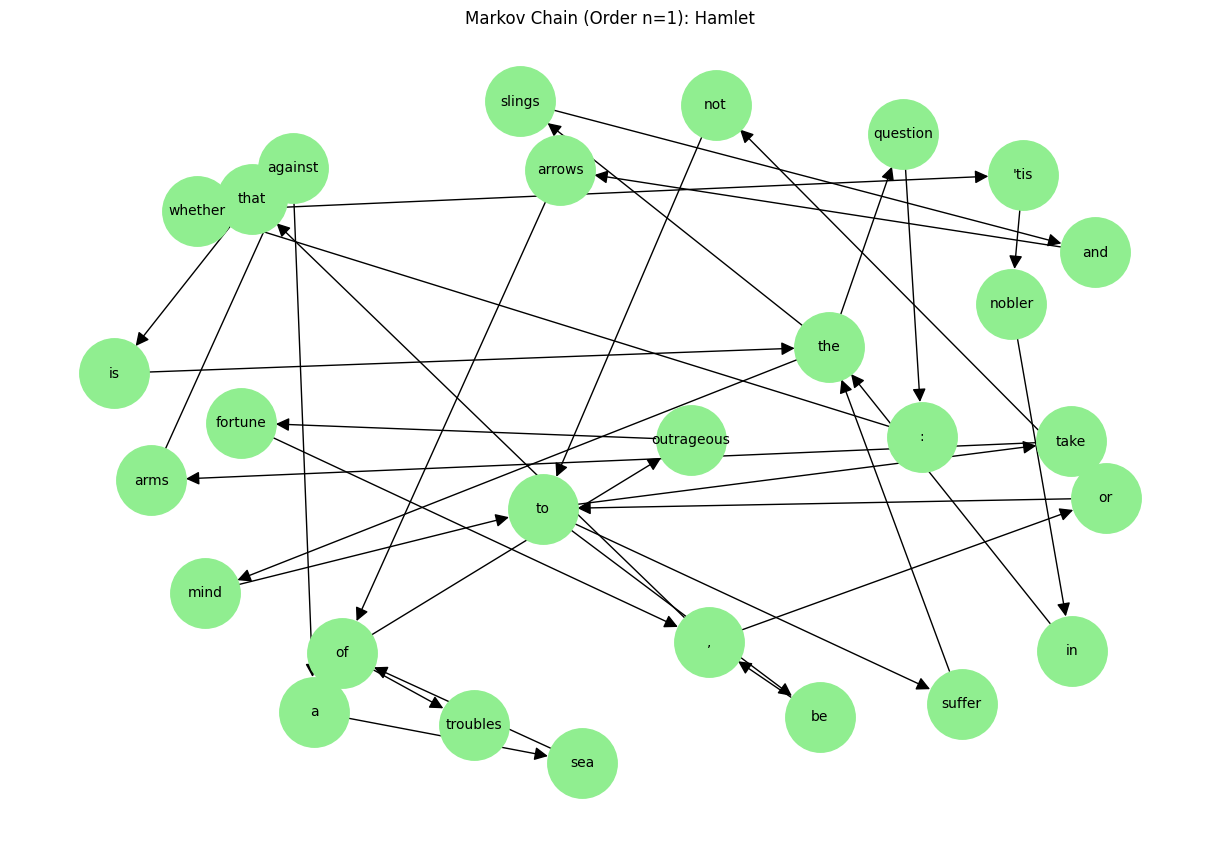

# Additional Stuff


## Frequency decay as we make progress

##2.  Update Probability (or Frequency as you move along the sentence generation , for ex. after I , if it predicts "am' , now the frequncy of am will be {current_frequency - 1}. and run till gets to zero.

### Rough IDEA:

starting with:

 'I': {'am': 2, 'code': 2},

 if PREDICTED "am" :

 'I': {'am': 1, 'code': 2},

 if predicted "am" again:

 'I': {'am': 0, 'code': 2},

predicted "code" :

 'I': {'am': 0, 'code': 1},

 predicted "code":

 'I': {'am': 0, 'code': 0},



## Higher-Order Markov Text Generator with Dynamic Frequency Update

Here , I will try tonexperiment with implementing a Markov chain text generator using Python. The goal is to train a model on a large text corpus and then generate new text that statistically resembles the original writing style.

For training data, I used the Gutenberg Corpus, specifically the novel Moby-Dick.

A Markov model works by learning which words tend to follow other words. After training, the program generates sentences by repeatedly predicting the next word based on previously observed patterns.




Instead of using only one previous word (1st order model), I extended the model to support second or third order Markov chains.

Using more previous words provides more context, which improves sentence quality.

Another improvement is updating word frequencies while generating the sentence. Rough idea sketched above .


### Possible Advantages:

Higher order models capture more context and produce sentences closer to the original text.

Reduce repitition. The frequency decay prevents loops. 


### Possible Drawbacks:

Might require more memory.

Will only stick to statical patterns.

Would not still understand whole sentance.



In [62]:
import random
import nltk
from nltk.corpus import gutenberg



class MarkovModel:

    def __init__(self, order):
        # order tells how many previous words we look at , will determine order os markov model
        self.order = order

        # dictionary that will store the transitions
        # example: ("Call","me") -> {"Ishmael": 3}
        self.lookup = {}   


    def train(self, words):

        
        for i in range(len(words) - self.order):      # go through the training text

            
            state = tuple(words[i:i + self.order]) # get the current state (n words



            # the next word after the given state
            next_word = words[i + self.order]

            # if this state has not been seen before, we will  add it
            if state not in self.lookup:
                self.lookup[state] = {}

            # make change in frequency count 
            if next_word not in self.lookup[state]:
                self.lookup[state][next_word] = 1
            else:
                self.lookup[state][next_word] += 1


    def choose_next_word(self, options):

        # calculate total frequency
        total = 0
        for v in options.values():
            total += v

        # if no words left we stop
        if total == 0:
            return None

        # pick random number
        r = random.randint(1, total)

        running_sum = 0

        # find which word corresponds to the random number
        for word in options:

            running_sum += options[word]

            if running_sum >= r:
                # decrease frequency after choosing it
                options[word] -= 1
                return word

        return None


    def generate(self, start_words, length=50):

        sentence = []

        # add starting words
        for w in start_words:
            sentence.append(w)

        current_state = tuple(start_words)

        for i in range(length):

            if current_state not in self.lookup:
                print("DEBUG: reached a state not in training data")
                break

            options = self.lookup[current_state]

            next_word = self.choose_next_word(options)

            if next_word is None:
                print("Done: no words left for this state")
                break

            sentence.append(next_word)

            # update state using last n words
            current_state = tuple(sentence[-self.order:])

        # combine all words into one string
        # we will add spaces between words
        final_text = ""

        for w in sentence:
            final_text += w + " "

        return final_text





# Example usage : Training on Moby Dick




words = gutenberg.words('melville-moby_dick.txt')

# using smaller portion for faster testing
small_words = list(words[:30000])


print("Second Order Markov Model")

model2 = MarkovModel(order=2)
model2.train(small_words)

print(model2.generate(["Call", "me"], 40))


print("\nThird Order Markov Model")

model3 = MarkovModel(order=3)
model3.train(small_words)

print(model3.generate(["Call", "me", "Ishmael"], 40))

Second Order Markov Model
Call me Ishmael . Some were thickly set with glittering teeth resembling ivory saws ; others were tufted with knots of human hair ; and one was of a newly developing bloom -- the Tyre of this earth ' s performances -- 

Third Order Markov Model
Call me Ishmael . Some years ago -- never mind now what that command was , or how conveyed -- which he found a hard command . But all in vain ; the indignant gale howls louder ; then , with one hand 


Second Order Markov Model
Call me Ishmael . Some were thickly set with glittering teeth resembling ivory saws ; others were tufted with knots of human hair ; and one was of a newly developing bloom -- the Tyre of this earth ' s performances -- 

Third Order Markov Model
Call me Ishmael . Some years ago -- never mind now what that command was , or how conveyed -- which he found a hard command . But all in vain ; the indignant gale howls louder ; then , with one hand 

### MY TAKE:

It seema a useful way to explore how simple probabilistic models can generate text.

The higher we go on markov order , we might get better accuracy based on training data, how it will also  loose its creativity at the same time.

